# ClusterFinder — CPU vs CUDA performance

Throughput comparison of the serial CPU finder against the CUDA variants:
per-frame, batched+pinned, CUDA-Graph, and the async double-buffered pipeline.

CPU↔CUDA **correctness** (why the cluster counts differ) is analysed
separately in `ClusterFinderFrozen_vs_CUDA.ipynb`; here we only sanity-check that
the counts and spectra agree, and focus on timing.

In [1]:
import sys; sys.path.append('/home/ferjao_k/aare/build')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import boost_histogram as bh
import time
from tqdm import tqdm

from aare import (File, ClusterFinder, ClusterFinderFrozen, ClusterFinderMT, ClusterCollector,
                  ClusterFinderCUDA, ClusterFinderCUDAGraph, ClusterFinderCUDAOpt2)
from helper import print_pinning_budget

import resource

def _faults():
    r = resource.getrusage(resource.RUSAGE_SELF)
    return r.ru_minflt, r.ru_majflt

In [2]:
N_BINS = 200

def make_hist(clusters):
    h = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    h.fill(clusters.sum())
    return h

def make_hist_from_batch(result_list):
    h = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    energies = [np.asarray(cv.sum()).ravel() for cv in result_list if cv.size > 0]
    if energies:
        h.fill(np.concatenate(energies))
    return h

In [3]:
base = Path('/mnt/sls_det_storage/moench_data/2603_MaxIVBeamtime/2026032408/process/xrf/')
f = File(base / 'Cu_factor_10_data_master_0.json')
pd = File(base / 'Cu_factor_10_pedestal_master_0.json')

n_frames_pd  = 1000
N            = 20000
cluster_size = (9, 9)
rows, cols   = f.rows, f.cols
image_size   = (rows, cols)
capacity     = 10000
BATCH_SIZE   = 2000

N_STREAMS = 4
N_SIGMA   = 5

# Cluster cap = the fixed-size per-frame output slot the kernel writes into and
# D2H copies WHOLE every frame, regardless of how full it is. MEASURED against
# the per-frame maximum, never guessed: 2 545 at 3x3 (100k frames), 1 633 at 9x9
# (20k). The earlier campaigns ran 9x9 at 1500, which is BELOW that maximum --
# the kernel guards only the write and the host clamps the count, so it silently
# dropped 2 715 clusters (0.0095%) and made a truncation artefact look like a
# CPU-vs-CUDA precision bug. Raising it is not free at 9x9: the slot grows
# 480.5 -> 544.5 KiB and D2H 22.8 -> 25.2 us/frame, which on the f32 build is
# the binding engine. See run_ladder.py CONFIGS and report section 8.
CAP = 1700 if cluster_size == (9, 9) else 3000

# Per-frame CUDA-event kernel timing. Off by default: it adds 2 event records
# per frame to the streams + a host query per frame, and the number is only
# meaningful at n_streams=1. Flip to True to A/B what the instrumentation costs.
TIME_KERNELS = False

# Build identity. DEVICE_PED_TYPE is a COMPILE-TIME axis (the opt6/opt7 arm), so
# it cannot be read back off a finder: device_pedestal() hands out an NDArray of
# the HOST pedestal type and upcasts, so its dtype is float64 on both builds.
# common.device_ped_type() parses the header instead, and assert_build_fresh()
# stops that from being a lie by refusing to run if any kernel header is newer
# than the compiled .so -- the exact failure that produced one quarantined
# probe set (results/2026-08-20_INVALID_stale_build).
sys.path.insert(0, '/home/ferjao_k/aare/python/tests/perf')
import common
common.assert_build_fresh()
ARM = common.device_ped_type()            # 'float' | 'double'

print(f'Build:           DEVICE_PED_TYPE = {ARM}')
print(f'Image size:      {image_size}')
print(f'Pedestal frames: {n_frames_pd}')
print(f'Data frames:     {N}')
print(f'Total in file:   {f.total_frames}')
print(f'Cluster cap:     {CAP}  (per-frame output slot; D2H copies it whole)')

Build:           DEVICE_PED_TYPE = double
Image size:      (400, 400)
Pedestal frames: 1000
Data frames:     20000
Total in file:   100000
Cluster cap:     1700  (per-frame output slot; D2H copies it whole)


In [4]:
print_pinning_budget(rows, cols)

── System RAM ──────────────────────────────────────────
  Total RAM           : 125.1 GiB
  Currently available : 62.3 GiB  (free + reclaimable cache)
  Reserved headroom   : 4.0 GiB  (OS + CUDA context)
  Safe pinning budget : 58.3 GiB

── Frame layout ────────────────────────────────────────
  Frame size          : 400 × 400 × 2 B = 312.5 kB

── Pinning estimate ────────────────────────────────────
  Max frames pinnable : 195,703  (58.3 GiB)

  Note: no swap on this machine — exceeding available RAM
  will trigger the OOM killer. Stay within the budget.


## Build finders

`SERIAL` picks the CPU baseline: the sequential `ClusterFinder` or the
multi-threaded `ClusterFinderMT`. All finders are trained on the same pedestal
frames below.

In [5]:
SERIAL = False

if SERIAL:
    # cf_cpu = ClusterFinder(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
    cf_cpu = ClusterFinderFrozen(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
else:
    # Thread count is per cluster size, measured (perf/cpu_threads.py): 24 is the
    # 3x3 optimum, 32 the 9x9 one. Past 32 the ClusterCollector drain -- which is
    # inside the timed region -- costs more than the extra workers buy, and 9x9
    # clusters are 9x larger, so the turnover happens later.
    cf_cpu = ClusterFinderMT(image_size, cluster_size, n_sigma=N_SIGMA,
                             capacity=capacity,
                             n_threads=32 if cluster_size == (9, 9) else 24)
    sink = ClusterCollector(cf_cpu)
    
cf_cuda_v1 = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                               max_clusters_per_frame=CAP,
                               n_streams=N_STREAMS, time_kernels=TIME_KERNELS)
cf_cuda    = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                               max_clusters_per_frame=CAP,
                               n_streams=N_STREAMS, time_kernels=TIME_KERNELS)
cf_graph   = ClusterFinderCUDAGraph(image_size, cluster_size, n_sigma=N_SIGMA,
                                    max_clusters_per_frame=CAP,
                                    n_streams=N_STREAMS)

## Pedestal (all finders trained on identical frames)

In [6]:
t0 = time.perf_counter()
for _ in range(n_frames_pd):
    img = pd.read_frame()
    cf_cpu.push_pedestal_frame(img.copy())
    cf_cuda_v1.push_pedestal_frame(img.copy())
    cf_cuda.push_pedestal_frame(img.copy())
    # cf_async.push_pedestal_frame(img.copy())
    cf_graph.push_pedestal_frame(img.copy())
print(f'Pedestal ({n_frames_pd} frames): {time.perf_counter() - t0:.3f}s')

Pedestal (1000 frames): 8.249s


## Read all data frames into memory (I/O out of the timing loop)

In [7]:
f.seek(0)
t0 = time.perf_counter()
data = f.read_n(N)
t_io = time.perf_counter() - t0
print(f'Reading {N} frames: {t_io:.3f}s  ({N/t_io:.0f} FPS, '
      f'{f.bytes_per_frame * N / 1024**2 / t_io:.3f} GB/s)')

Reading 20000 frames: 11.106s  (1801 FPS, 549.573 GB/s)


## CPU clustering (baseline)

In [8]:
mf0, Mf0 = _faults()
t0 = time.perf_counter()
for frame in tqdm(data):
    cf_cpu.find_clusters(frame)
t_cpu = time.perf_counter() - t0
mf1, Mf1 = _faults()   # bracket the timed loop only; MT drain + hist below allocate too

if SERIAL:
    clusters_cpu = cf_cpu.steal_clusters(realloc_same_capacity=False)
    n_clusters_cpu = clusters_cpu.size
    hist_cpu = make_hist(clusters_cpu)
else:
    cf_cpu.stop(); sink.stop()
    clusters_cpu = sink.steal_clusters()
    hist_cpu = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    n_clusters_cpu = 0
    for cv in clusters_cpu:
        hist_cpu.fill(cv.sum())
        n_clusters_cpu += cv.size

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'CPU clustering:       {t_cpu:.3f}s ({N/t_cpu:.0f} FPS, '
      f'{n_clusters_cpu} clusters, {n_clusters_cpu/N:.2f}/frame)')

100%|███████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:11<00:00, 1674.96it/s]


  minor faults:       2,010,077  (~1.41s est.)   major: 2
CPU clustering:       11.944s (1674 FPS, 28438219 clusters, 1421.91/frame)


## CUDA — per-frame (1 launch/frame, pageable memory)
Simplest path: no batching, no pinning. Isolates per-frame launch + PCIe overhead.

In [9]:
cf_cuda_v1.reset_timers()
mf0, Mf0 = _faults()
t0 = time.perf_counter()

n_clusters_cuda_v1 = 0
hist_cuda_v1 = None
for frame in data:
    cf_cuda_v1.find_clusters(frame)
    clusters_frame = cf_cuda_v1.steal_clusters(realloc_same_capacity=True)
    n_clusters_cuda_v1 += clusters_frame.size
    h = make_hist(clusters_frame)
    hist_cuda_v1 = h if hist_cuda_v1 is None else hist_cuda_v1 + h

t_cuda_v1 = time.perf_counter() - t0
mf1, Mf1 = _faults()
kernel_ms = cf_cuda_v1.avg_kernel_time_ms()
print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'CUDA per-frame:       {t_cuda_v1:.3f}s  ({N/t_cuda_v1:.0f} FPS, '
      f'{n_clusters_cuda_v1} clusters, {n_clusters_cuda_v1/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_cuda_v1*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/CUDA):   {t_cpu / t_cuda_v1:.2f}x')

  minor faults:       2,327  (~0.00s est.)   major: 6
CUDA per-frame:       4.143s  (4828 FPS, 28449389 clusters, 1422.47/frame)
  Kernel only:        nan ms/frame
  PCIe + overhead:    nan ms/frame
Speedup (CPU/CUDA):   2.88x


## CUDA — batched + multi-streamed + pinned dataset
Pins the whole input once, then submits `BATCH_SIZE`-frame chunks across `N_STREAMS` streams so H2D / kernel / D2H overlap.

In [17]:
cf_cuda.register_input_buffer(data)   # pin the whole dataset once
clusters_cuda_per_frame = []

cf_cuda.reset_timers()
mf0, Mf0 = _faults()
t0 = time.perf_counter()
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_cuda_per_frame.extend(
        cf_cuda.find_clusters_batched(data[start:stop], first_frame=start))
t_cuda = time.perf_counter() - t0
mf1, Mf1 = _faults()   # before make_hist_from_batch, which allocates GBs itself

cf_cuda.unregister_input_buffer()
kernel_ms = cf_cuda.avg_kernel_time_ms()
n_clusters_cuda = sum(cv.size for cv in clusters_cuda_per_frame)
hist_cuda = make_hist_from_batch(clusters_cuda_per_frame)

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'CUDA batched:         {t_cuda:.3f}s total | {t_cuda*1000/N:.3f} ms/frame ({N/t_cuda:.0f} FPS, '
      f'{n_clusters_cuda} clusters, {n_clusters_cuda/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_cuda*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/CUDA):   {t_cpu / t_cuda:.2f}x')

  minor faults:       165  (~0.00s est.)   major: 0
CUDA batched:         1.388s total | 0.069 ms/frame (14405 FPS, 28452038 clusters, 1422.60/frame)
  Kernel only:        nan ms/frame
  PCIe + overhead:    nan ms/frame
Speedup (CPU/CUDA):   8.60x


## Async pipeline — is the wall clock host-bound?

Diagnostic for the "next moves" slide. Both loops submit **slices of the already-pinned
`data`**, so neither pays a staging memcpy (the two-buffer pattern in the cell below is
only needed when frames are streamed in, not when the whole dataset is pinned in RAM).

- **serial**   `submit(b); collect(b)`  -> GPU + host, serialized
- **pipelined** `submit(b+1)` before `collect(b)` -> max(GPU, host)

`serial - pipelined` = min(GPU, host), i.e. how much time is hideable. Compare
`pipelined` against the exclusive GPU floor from nsys (`nsys_kernel_probe.py`) to see
which of the two is the real limit. Re-run the cell until minor faults plateau.

In [18]:
# Async pipeline vs serial — no staging memcpy, slices of the pinned dataset.
# Drop the previous run's results FIRST. Otherwise the old res_pipe (~9.3 GB at
# 9x9) is still alive while the serial loop allocates its own, so the heap has to
# grow and the fault count never plateaus. res_pipe = [] below is too late: it
# frees inside the timed section.
for _v in ('res_serial', 'res_pipe'):
    globals().pop(_v, None)

# The serial loop is a reference point, but it also doubles as an accidental
# warm-up: it leaves both the heap and the pinned slots hot for the pipelined
# loop below. Set False to time the pipelined loop on its own and check that the
# fault count really is zero rather than merely absorbed upstream.
RUN_SERIAL = False

cf_async = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                             max_clusters_per_frame=CAP,
                             n_streams=N_STREAMS, time_kernels=TIME_KERNELS)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_async.push_pedestal_frame(pd.read_frame().copy())

cf_async.register_input_buffer(data)          # pin once; both loops reuse it
bounds = [(s, min(s + BATCH_SIZE, N)) for s in range(0, N, BATCH_SIZE)]

# Pre-pin both output slots OUTSIDE any timed region. submit_batch() honours the
# batch size it is handed — MAX_SLOT_BYTES caps only the *auto* chunk — so these
# slots are BATCH_SIZE frames each: 240 MB at 3x3, 984 MB at 9x9, times two.
# Allocated lazily that is ~120 ms / ~480 ms of page-locking landing inside
# whichever loop runs first. Allocates only: no transfer, no launch, and the
# pedestal is NOT advanced, so cf_async stays comparable with the other finders.

cf_async.reserve_output_slots(BATCH_SIZE)

# ---- 1. SERIAL: submit then immediately collect (no overlap) ----------------
if RUN_SERIAL:
    cf_async.reset_timers()
    mf0, Mf0 = _faults()
    t0 = time.perf_counter()
    res_serial = []
    for a, b in bounds:
        tok = cf_async.submit_batch(data[a:b], first_frame=a)
        res_serial.extend(cf_async.collect(tok))
    t_serial = time.perf_counter() - t0
    mf1, Mf1 = _faults()
    f_serial = mf1 - mf0
    n_serial = sum(cv.size for cv in res_serial)
    del res_serial                             # free before the next loop

# ---- 2. PIPELINED: keep one batch in flight while collecting the previous ---
# Reset again: avg_kernel_time_ms() is total_kernel_ms / frames_processed, and
# both loops accumulate into the same counters. Without this the kernel time
# printed below is an average over 40 000 frames from two different regimes.
cf_async.reset_timers()
mf2, Mf2 = _faults()
t0 = time.perf_counter()
res_pipe = []
tok = cf_async.submit_batch(data[bounds[0][0]:bounds[0][1]], first_frame=bounds[0][0])
for a, b in bounds[1:]:
    nxt = cf_async.submit_batch(data[a:b], first_frame=a)   # GPU starts batch N+1
    res_pipe.extend(cf_async.collect(tok))                  # host materializes batch N
    tok = nxt
res_pipe.extend(cf_async.collect(tok))                      # drain the last one
t_pipe = time.perf_counter() - t0
mf3, Mf3 = _faults()
f_pipe = mf3 - mf2
n_clusters_async = sum(cv.size for cv in res_pipe)
hist_async = make_hist_from_batch(res_pipe)

cf_async.unregister_input_buffer()

us = lambda t: t * 1e6 / N
print(f'  minor faults:  ' + (f'serial {f_serial:,}   ' if RUN_SERIAL else '')
      + f'pipelined {f_pipe:,}   (slots pre-pinned; the rest is result heap)')
print("=========================================================================================")
if RUN_SERIAL:
    print(f'serial    (GPU + host):   {t_serial:.3f}s  ({N/t_serial:8,.0f} FPS)  {us(t_serial):6.1f} us/frame  '
          f'{n_serial} clusters')
print(f'pipelined (max of both):  {t_pipe:.3f}s  ({N/t_pipe:8,.0f} FPS)  {us(t_pipe):6.1f} us/frame  '
      f'{n_clusters_async} clusters')
if RUN_SERIAL:
    print(f'  hidden by overlap:      {us(t_serial) - us(t_pipe):6.1f} us/frame   = min(GPU, host)')
    print(f'  speedup pipelined/serial:  {t_serial / t_pipe:.2f}x')
try:
    print(f'  vs find_clusters_batched:  {t_cuda / t_pipe:.2f}x   '
          f'({us(t_cuda):.1f} -> {us(t_pipe):.1f} us/frame)')
except NameError:
    pass
print(f'  kernel (event timer):   {cf_async.avg_kernel_time_ms()*1000:6.1f} us/frame  '
      f'(inflated under {N_STREAMS} streams — use nsys for the true value)')
print()
print('Interpretation: if pipelined ~= the nsys GPU floor, the remaining cost was host-side')
print('and is now hidden. If pipelined stays well above it, the host is the binding limit.')


  minor faults:  pipelined 2   (slots pre-pinned; the rest is result heap)
pipelined (max of both):  1.362s  (  14,685 FPS)    68.1 us/frame  28441991 clusters
  vs find_clusters_batched:  1.02x   (69.4 -> 68.1 us/frame)
  kernel (event timer):      nan us/frame  (inflated under 4 streams — use nsys for the true value)

Interpretation: if pipelined ~= the nsys GPU floor, the remaining cost was host-side
and is now hidden. If pipelined stays well above it, the host is the binding limit.


## CUDA — Graph (pinned dataset)
Pre-records the H2D->kernel->D2H pipeline as a CUDA Graph per stream, cutting per-frame CPU API overhead (~21 us vs ~60 us for the streamed version).

In [19]:
cf_graph.register_input_buffer(data)
clusters_graph_per_frame = []

mf0, Mf0 = _faults()
t0 = time.perf_counter()
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_graph_per_frame.extend(
        cf_graph.find_clusters_batched(data[start:stop], first_frame=start))
t_graph = time.perf_counter() - t0
mf1, Mf1 = _faults()   # before make_hist_from_batch, which allocates GBs itself

cf_graph.unregister_input_buffer()
n_clusters_graph = sum(cv.size for cv in clusters_graph_per_frame)
hist_graph = make_hist_from_batch(clusters_graph_per_frame)

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'CUDA Graph:           {t_graph:.3f}s  ({N/t_graph:.0f} FPS, '
      f'{n_clusters_graph} clusters, {n_clusters_graph/N:.2f}/frame)')
print(f'  Kernel only:        {cf_graph.avg_kernel_time_ms():.3f} ms/frame')
print(f'  Kernel+PCIe+ovhd:   {t_graph*1000/N:.3f} ms/frame  (kernel not individually timed)')
print(f'Speedup (vs batched): {t_cuda / t_graph:.2f}x')
print(f'Speedup (CPU/Graph):  {t_cpu / t_graph:.2f}x')

  minor faults:       0  (~0.00s est.)   major: 0
CUDA Graph:           1.550s  (12901 FPS, 28452038 clusters, 1422.60/frame)
  Kernel only:        nan ms/frame
  Kernel+PCIe+ovhd:   0.078 ms/frame  (kernel not individually timed)
Speedup (vs batched): 0.90x
Speedup (CPU/Graph):  7.70x


## Zero-copy collection — `collect_view()`

`find_clusters_batched` / `collect()` allocate one `ClusterVector` **per frame** and copy
into it. `collect_view()` copies nothing: the pinned D2H buffer already holds correctly
laid-out clusters at a fixed per-frame stride, so the view just exposes offsets into it.

The copy it removes is **~8 us/frame at 3x3 and ~40 us/frame at 9x9** (bytes / memcpy
bandwidth). What that is *worth* end to end is `max(0, copy - GPU floor)`, so the two
sizes pay very differently: 19.8 -> 17.1 us/frame at 3x3 (x1.16, the copy mostly hid
under the GPU already) but 66.4 -> 30.0 at 9x9 (x2.21, where it could not hide at any
overlap). Both are `[f64]`, warm, 5 reps -- report section 8.

The view borrows the finder's slot and is released at the end of each loop iteration,
so **anything you need afterwards must be copied out**. `sums()` returns an owned array
and is safe; `frame_data(i)` / `frame_xy(i)` are views and are not.

`sums()` is timed separately below: `collect()` copies but does not reduce, so comparing
it against `collect_view()` + `sums()` compares different work. The bare line is the one
to put next to the batched / graph / async cells.

In [20]:
# Zero-copy collection vs the collect() cells above.
from aare import find_cluster_views_batched_iter

# Set False to time the transport alone (no reduction, no histogram) — that is
# the GPU-pipeline number to compare against the nsys roofline.
WITH_ANALYSIS = False

# Roofline = 1 / max(kernel, H2D, D2H), each term that engine's BUSY TIME per
# frame -- the union of its intervals, not a duration -- at n_streams=4, and
# taken as the LOWER of two estimates: the nsys probe, and the best rate the
# unprofiled pipeline sustained. Source: perf/results/2026-08-20_{f32,f64}_cap1700
# probes.csv via gpu_span.py; the table is section 4 of the report.
#
#   arm      size  cap   probe  sustained   PEAK    binds
#   double   3x3   3000  16.17    17.10     16.17   H2D
#   float    3x3   3000  16.63    16.31     16.31   H2D
#   double   9x9   1700  32.66    30.01     30.01   kernel
#   float    9x9   1700  25.24    25.14     25.14   D2H  (opt7 put the kernel under it)
#
# Neither estimate is exact and the two bracket the truth to ~2%, so a run that
# lands BETWEEN them (16.5 us on f32 3x3, say) is at the floor, not short of it.
PEAK_US = {('double', (3, 3)): 16.17, ('float', (3, 3)): 16.31,
           ('double', (9, 9)): 30.01, ('float', (9, 9)): 25.14}
GPU_FLOOR_US = PEAK_US[(ARM, cluster_size)]      # ARM comes from the config cell

cf_zc = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                          max_clusters_per_frame=CAP,
                          n_streams=N_STREAMS, time_kernels=TIME_KERNELS)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_zc.push_pedestal_frame(pd.read_frame().copy())
cf_zc.register_input_buffer(data)

# Pre-pin the two output slots OUTSIDE the timing. This allocates only; it
# transfers nothing and launches nothing, so the pedestal is NOT advanced —
# unlike running frames through as a warm-up, which would leave cf_zc with a
# pedestal 8000 steps ahead of every other finder here.
CHUNK = cf_zc.chunk_size_for(N)
cf_zc.reserve_output_slots(CHUNK)

hist_B = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
n_B = 0
t_sums = 0.0      # C++ reduction over the pinned buffer
t_hist = 0.0      # boost_histogram fill

mf0, _ = _faults()
t0 = time.perf_counter()
for v in find_cluster_views_batched_iter(cf_zc, data, chunk=CHUNK):
    if not WITH_ANALYSIS:
        continue
    _t = time.perf_counter(); s = v.sums();   t_sums += time.perf_counter() - _t
    n_B += s.size
    _t = time.perf_counter(); hist_B.fill(s); t_hist += time.perf_counter() - _t
t_B = time.perf_counter() - t0
f_B = _faults()[0] - mf0
cf_zc.unregister_input_buffer()

us = lambda t: t * 1e6 / N
pc = lambda t: 100 * GPU_FLOOR_US / us(t)
t_bare = t_B - t_sums - t_hist

print(f'  minor faults:  {f_B:,}   (should be ~0 after the warm-up above)')
print(f'  chunk: {cf_zc.chunk_size_for(N)} frames/chunk   '
      f'build {ARM} - cap {CAP} - {N_STREAMS} streams')
print("=========================================================================================")
print(f'GPU roofline (report 4): {GPU_FLOOR_US:6.1f} us/frame  ({1e6/GPU_FLOOR_US:8,.0f} FPS)  '
      f'= 1 / max(kernel, H2D, D2H)')
print(f'==> transport only:      {us(t_bare):6.1f} us/frame  ({N/t_bare:8,.0f} FPS)  '
      f'{pc(t_bare):3.0f}% of roofline')
if WITH_ANALYSIS:
    print(f'   + sums():             {us(t_sums):6.1f} us/frame')
    print(f'   + histogram:          {us(t_hist):6.1f} us/frame')
    print(f'    = total:             {us(t_B):6.1f} us/frame  ({N/t_B:8,.0f} FPS)  '
          f'{pc(t_B):3.0f}% of roofline   {n_B} clusters')
try:
    print()
    print(f'find_clusters_batched:   {us(t_cuda):6.1f} us/frame  ({N/t_cuda:8,.0f} FPS)  '
          f'{pc(t_cuda):3.0f}% of roofline   (copies clusters, no reduction)')
    print(f'  -> zero-copy transport is {t_cuda/t_bare:.2f}x')
except NameError:
    pass


  minor faults:  0   (should be ~0 after the warm-up above)
  chunk: 240 frames/chunk   build double - cap 1700 - 4 streams
GPU roofline (report 4):   30.0 us/frame  (  33,322 FPS)  = 1 / max(kernel, H2D, D2H)
==> transport only:        30.9 us/frame  (  32,355 FPS)   97% of roofline

find_clusters_batched:     69.4 us/frame  (  14,405 FPS)   43% of roofline   (copies clusters, no reduction)
  -> zero-copy transport is 2.25x


## Agreement sanity check
Counts should match to a hair. The residual comes from the CUDA finder updating the pedestal once per frame vs the CPU's per-pixel update (analysed in `ClusterFinderFrozen_vs_CUDA.ipynb`).

In [14]:
rows = [('CPU', n_clusters_cpu), ('CUDA per-frame', n_clusters_cuda_v1),
        ('CUDA batched', n_clusters_cuda), ('CUDA graph', n_clusters_graph),
        ('CUDA async', n_clusters_async)]
if globals().get('n_B'):   # 0 when WITH_ANALYSIS=False: nothing counted
    rows.append(('zero-copy view', n_B))

for name, n in rows:
    d = abs(n - n_clusters_cpu)
    print(f'  {name:<18} {n:>12,}   diff vs CPU {d:>6,}  ({d/max(n_clusters_cpu,1):.4%})')


  CPU                  28,438,219   diff vs CPU      0  (0.0000%)
  CUDA per-frame       28,449,389   diff vs CPU 11,170  (0.0393%)
  CUDA batched         28,441,991   diff vs CPU  3,772  (0.0133%)
  CUDA graph           28,441,991   diff vs CPU  3,772  (0.0133%)
  CUDA async           28,441,991   diff vs CPU  3,772  (0.0133%)


## Spectrum: CPU vs CUDA variants

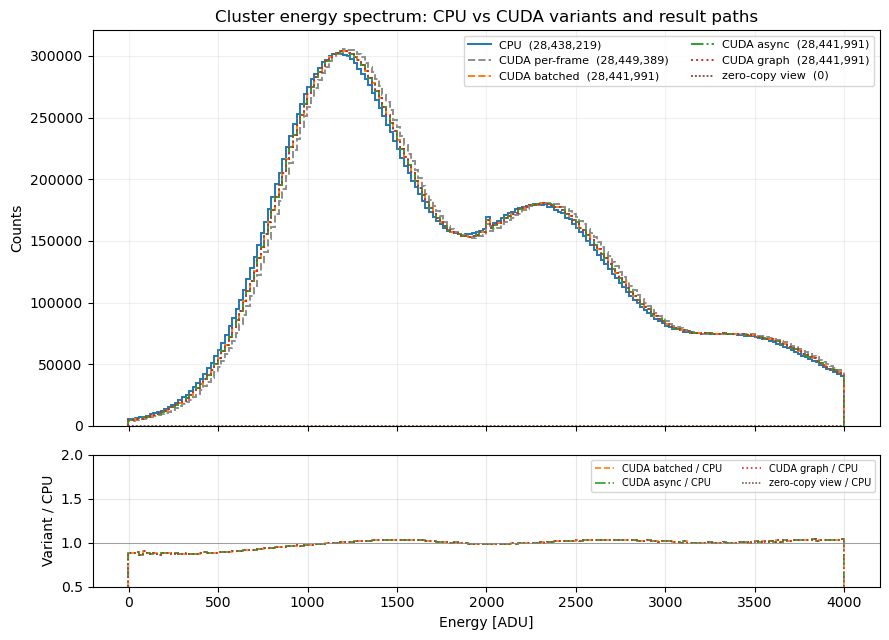

In [15]:
fig, (ax_spec, ax_ratio) = plt.subplots(
    2, 1, figsize=(9, 6.5), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]})

edges = hist_cpu.axes[0].edges

# (label, histogram, cluster count, linestyle, colour). The result-path rows are
# appended only if the zero-copy cell has been run.
series = [
    ('CPU',                  hist_cpu,     n_clusters_cpu,     '-',  'C0'),
    ('CUDA per-frame',       hist_cuda_v1, n_clusters_cuda_v1, '--', '0.55'),
    ('CUDA batched',         hist_cuda,    n_clusters_cuda,    '--', 'C1'),
    ('CUDA async',           hist_async,   n_clusters_async,   '-.', 'C2'),
    ('CUDA graph',           hist_graph,   n_clusters_graph,   ':',  'C3'),
]
if 'hist_B' in globals():
    series.append(('zero-copy view', hist_B, n_B, (0, (1, 1)), 'C5'))

for label, h, n, ls, col in series:
    ax_spec.stairs(h.values(), edges, label=f'{label}  ({n:,})',
                   linestyle=ls, color=col, linewidth=1.4)

ax_spec.set_ylabel('Counts')
ax_spec.set_title('Cluster energy spectrum: CPU vs CUDA variants and result paths')
ax_spec.legend(fontsize=8, ncol=2)
ax_spec.grid(alpha=0.2)

# Ratio panel: everything against the CPU reference. All curves should sit on 1;
# departures are the pedestal-update difference, not the result path.
cpu_vals = hist_cpu.values()
with np.errstate(divide='ignore', invalid='ignore'):
    for label, h, n, ls, col in series[2:]:      # skip CPU itself and v1
        r = np.where(cpu_vals > 0, h.values() / cpu_vals, np.nan)
        ax_ratio.stairs(r, edges, label=f'{label} / CPU',
                        linestyle=ls, color=col, linewidth=1.2)

ax_ratio.axhline(1.0, color='gray', linewidth=0.5)
ax_ratio.set_ylabel('Variant / CPU')
ax_ratio.set_xlabel('Energy [ADU]')
ax_ratio.set_ylim(0.5, 2.0)
ax_ratio.legend(fontsize=7, ncol=2)
ax_ratio.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Optimization arc for the deck (opt1 → opt2 → opt3)

Same pedestal and `data` as above, scored against the CPU baseline (`t_cpu`, `n_clusters_cpu`). Each cell is self-contained: it builds its finder, trains the pedestal, and runs.

- **opt1** — first CUDA port: `ClusterFinderCUDAOpt2`, single stream, one launch per frame (pre-refactor pipeline, pageable H2D).
- **opt2** — multi-stream + batching: `ClusterFinderCUDAOpt2`, `n_streams=4`, `find_clusters_batched` (still pre-refactor, pageable H2D).
- **opt3** — current finder, batched but **without** input pinning: `ClusterFinderCUDA.find_clusters_batched` on pageable memory (no `register_input_buffer`). The pinned + Graph + async steps are the batched/graph cells above.

Correctness is held constant across the arc: the Test3 local-max gate has been backported into the opt2 kernel, so opt1/opt2 counts match the CPU and current finders — only the pipeline changes from step to step.

In [16]:
# opt1 — first port: ClusterFinderCUDAOpt2, single stream, one launch per frame
cf_opt1 = ClusterFinderCUDAOpt2(image_size, cluster_size, n_sigma=N_SIGMA,
                                max_clusters_per_frame=CAP, n_streams=1)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_opt1.push_pedestal_frame(pd.read_frame().copy())

cf_opt1.reset_timers()
mf0, Mf0 = _faults()
t0 = time.perf_counter()
n_clusters_opt1 = 0
for i, frame in enumerate(data):
    cf_opt1.find_clusters(frame, frame_number=i)
    n_clusters_opt1 += cf_opt1.steal_clusters(realloc_same_capacity=True).size
t_opt1 = time.perf_counter() - t0
mf1, Mf1 = _faults()
kernel_ms = cf_opt1.avg_kernel_time_ms()

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'opt1 per-frame:        {t_opt1:.3f}s  ({N/t_opt1:.0f} FPS, '
      f'{n_clusters_opt1} clusters, {n_clusters_opt1/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_opt1*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/opt1):   {t_cpu / t_opt1:.2f}x')

ValueError: Unsupported combination of type and cluster size: <class 'numpy.int32'>/(9, 9) when requesting ClusterFinderCUDAOpt2_Cluster9x9i

In [ ]:
# opt2 — multi-stream + batching: ClusterFinderCUDAOpt2, pageable H2D (no pinning)
cf_opt2 = ClusterFinderCUDAOpt2(image_size, cluster_size, n_sigma=N_SIGMA,
                                max_clusters_per_frame=CAP, n_streams=N_STREAMS)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_opt2.push_pedestal_frame(pd.read_frame().copy())

cf_opt2.reset_timers()
mf0, Mf0 = _faults()
t0 = time.perf_counter()
clusters_opt2 = []
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_opt2.extend(cf_opt2.find_clusters_batched(data[start:stop], first_frame=start))
t_opt2 = time.perf_counter() - t0
mf1, Mf1 = _faults()
kernel_ms = cf_opt2.avg_kernel_time_ms()
n_clusters_opt2 = sum(cv.size for cv in clusters_opt2)

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'opt2 batched (no pin): {t_opt2:.3f}s  ({N/t_opt2:.0f} FPS, '
      f'{n_clusters_opt2} clusters, {n_clusters_opt2/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_opt2*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/opt2):   {t_cpu / t_opt2:.2f}x')
print(f'Speedup (opt1/opt2):  {t_opt1 / t_opt2:.2f}x')

In [ ]:
# opt3 — current finder, batched but WITHOUT input pinning (pageable H2D)
cf_opt3 = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                            max_clusters_per_frame=CAP, n_streams=N_STREAMS,
                            time_kernels=TIME_KERNELS)
pd.seek(0)
for _ in range(n_frames_pd):
    cf_opt3.push_pedestal_frame(pd.read_frame().copy())

cf_opt3.reset_timers()
mf0, Mf0 = _faults()
t0 = time.perf_counter()
clusters_opt3 = []
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_opt3.extend(cf_opt3.find_clusters_batched(data[start:stop], first_frame=start))
t_opt3 = time.perf_counter() - t0
mf1, Mf1 = _faults()
kernel_ms = cf_opt3.avg_kernel_time_ms()
n_clusters_opt3 = sum(cv.size for cv in clusters_opt3)

print(f'  minor faults:       {mf1-mf0:,}  (~{(mf1-mf0)*0.7e-6:.2f}s est.)   major: {Mf1-Mf0:,}')
print("=========================================================================================")
print(f'opt3 batched (no pin): {t_opt3:.3f}s  ({N/t_opt3:.0f} FPS, '
      f'{n_clusters_opt3} clusters, {n_clusters_opt3/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_opt3*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/opt3):   {t_cpu / t_opt3:.2f}x')
print(f'Speedup (opt2/opt3):  {t_opt2 / t_opt3:.2f}x')